# TabNet Hyperparameter Tuning for Customer Churn

This notebook tunes a `pytorch-tabnet` classifier with Optuna, using the supplied train/validation/test split. The preprocessing is fit on the training data only, supports categorical columns when present, and preserves the validation set for early stopping and objective scoring.

The loader resolves the target column case-insensitively, so it works with both `churn` and the current dataset's `Churn` spelling.

In [1]:
# Optional, run once if the environment does not already contain these packages.
# %pip install optuna pytorch-tabnet scikit-learn seaborn matplotlib joblib

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import seaborn as sns
import torch

from optuna.samplers import TPESampler
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
N_TRIALS = 10
MAX_EPOCHS = 20
PATIENCE = 5
BATCH_SIZE = 2048
VIRTUAL_BATCH_SIZE = 256
ARTIFACT_DIR = Path("tabnet_optuna_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Optuna version: {optuna.__version__}")
print(f"PyTorch device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\User\ODL_Labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna version: 4.9.0
PyTorch device: cuda


In [ ]:
# Load the train/validation/test datasets
train_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\train_churn_dataset.csv")
val_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\val_churn_dataset.csv")
test_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\test_churn_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

In [ ]:
# Set target column and identify feature columns
TARGET = "Churn"
feature_names = [col for col in train_df.columns if col != TARGET]

# Prepare training, validation, and test datasets for TabNet
X_train = train_df[feature_names].astype(np.float32)
y_train = train_df[TARGET].astype(np.int64)

X_val = val_df[feature_names].astype(np.float32)
y_val = val_df[TARGET].astype(np.int64)

X_test = test_df[feature_names].astype(np.float32)
y_test = test_df[TARGET].astype(np.int64)

In [3]:
def encode_target(train_frame, val_frame, test_frame, target_column):
    """Encode target labels from the training split and reject unseen labels."""
    classes, train_codes = np.unique(train_frame[target_column], return_inverse=True)
    class_to_code = {value: index for index, value in enumerate(classes)}

    def encode(frame):
        unseen = sorted(set(frame[target_column].dropna()) - set(class_to_code))
        if unseen:
            raise ValueError(f"Unseen target labels in {target_column}: {unseen}")
        if frame[target_column].isna().any():
            raise ValueError(f"Missing target labels found in {target_column}.")
        return frame[target_column].map(class_to_code).to_numpy(dtype=np.int64)

    return encode(train_frame), encode(val_frame), encode(test_frame), classes


def prepare_tabnet_features(train_frame, val_frame, test_frame, columns):
    """Fit train-only feature encoders and return arrays plus TabNet categorical metadata."""
    train_features = train_frame[columns].copy()
    val_features = val_frame[columns].copy()
    test_features = test_frame[columns].copy()
    categorical_columns = [
        column
        for column in columns
        if (
            pd.api.types.is_object_dtype(train_features[column])
            or pd.api.types.is_categorical_dtype(train_features[column])
            or pd.api.types.is_bool_dtype(train_features[column])
        )
    ]
    numeric_columns = [column for column in columns if column not in categorical_columns]

    for column in numeric_columns:
        numeric_train = pd.to_numeric(train_features[column], errors="coerce")
        median = numeric_train.median()
        if pd.isna(median):
            raise ValueError(f"Numeric feature '{column}' has no usable training values.")
        for frame in (train_features, val_features, test_features):
            frame[column] = pd.to_numeric(frame[column], errors="coerce").fillna(median)

    cat_idxs = []
    cat_dims = []
    for column in categorical_columns:
        categories = pd.Index(train_features[column].dropna().unique())
        category_to_index = {value: index + 1 for index, value in enumerate(categories)}
        for frame in (train_features, val_features, test_features):
            encoded = frame[column].map(category_to_index).fillna(0).astype(np.int64)
            frame[column] = encoded
        cat_idxs.append(columns.index(column))
        cat_dims.append(len(categories) + 1)  # index 0 is reserved for unknown/missing values

    X_train = train_features.to_numpy(dtype=np.float32)
    X_val = val_features.to_numpy(dtype=np.float32)
    X_test = test_features.to_numpy(dtype=np.float32)
    if not all(np.isfinite(array).all() for array in (X_train, X_val, X_test)):
        raise ValueError("Feature arrays contain non-finite values after preprocessing.")
    return X_train, X_val, X_test, cat_idxs, cat_dims, categorical_columns


y_train, y_val, y_test, class_labels = encode_target(
    train_df, val_df, test_df, target_col
)
X_train, X_val, X_test, cat_idxs, cat_dims, categorical_columns = prepare_tabnet_features(
    train_df, val_df, test_df, feature_columns
)

if len(class_labels) != 2:
    raise ValueError(f"This notebook expects binary churn labels, found {len(class_labels)} classes.")

print(f"Feature matrix shapes: {X_train.shape}, {X_val.shape}, {X_test.shape}")
print(f"Categorical columns: {categorical_columns}")
print(f"cat_idxs={cat_idxs}; cat_dims={cat_dims}")
print(f"Encoded target classes: {list(class_labels)}")

Feature matrix shapes: (314599, 12), (67414, 12), (67415, 12)
Categorical columns: []
cat_idxs=[]; cat_dims=[]
Encoded target classes: [np.int64(0), np.int64(1)]


C:\Users\User\AppData\Local\Temp\ipykernel_50376\1085623978.py:27: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(train_features[column])


In [4]:
def build_tabnet(params):
    """Create a classifier from an Optuna parameter dictionary."""
    return TabNetClassifier(
        n_d=params["n_d"],
        n_a=params["n_d"],
        n_steps=params["n_steps"],
        gamma=params["gamma"],
        lambda_sparse=1e-4,
        mask_type="sparsemax",
        # cat_idxs=cat_idxs,
        # cat_dims=cat_dims,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={
            "lr": params["learning_rate"],
            "weight_decay": 1e-5,
        },
        seed=SEED,
        verbose=1,
        device_name="auto",
    )


In [5]:
def objective(trial):
    n_d = trial.suggest_int("n_d", 8, 64, step=8)
    params = {
        "n_d": n_d,
        "n_a": n_d,  # tied
        "n_steps": trial.suggest_int("n_steps", 3, 8),
        "gamma": trial.suggest_categorical("gamma", [1.0, 2.0]),
        "lambda_sparse": 1e-4,
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-2, log=True),
        "weight_decay": 1e-5,
        "mask_type": "sparsemax",
    }
    model = build_tabnet(params)
    model.fit(
        X_train=X_train,
        y_train=y_train,
        eval_set=[(X_val, y_val)],
        eval_name=["valid"],
        eval_metric=["logloss"],
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        batch_size=BATCH_SIZE,
        virtual_batch_size=VIRTUAL_BATCH_SIZE,
        num_workers=0,
        drop_last=False,
    )
    validation_probability = model.predict_proba(X_val)[:, 1]
    validation_auc = roc_auc_score(y_val, validation_probability)
    trial.set_user_attr("validation_auc", float(validation_auc))
    trial.set_user_attr("best_epoch", int(model.best_epoch))
    return validation_auc

print("Objective function is ready.")

Objective function is ready.


### Run the Optuna study

This runs `N_TRIALS` trials of TPE-based search, optimizing validation AUC. Each trial trains a TabNet model with early stopping on the validation set, so this cell can take a while depending on `N_TRIALS`, `MAX_EPOCHS`, and hardware.

In [6]:
sampler = TPESampler(seed=SEED)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="tabnet_churn",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

[I 2026-09-07 12:27:39,542] A new study created in memory with name: tabnet_churn
  0%|          | 0/10 [00:00<?, ?it/s]

epoch 0  | loss: 1.05416 | valid_logloss: 0.63526 |  0:00:12s
epoch 1  | loss: 0.53545 | valid_logloss: 0.46751 |  0:00:24s
epoch 2  | loss: 0.4487  | valid_logloss: 0.42309 |  0:00:35s
epoch 3  | loss: 0.40961 | valid_logloss: 0.39244 |  0:00:47s
epoch 4  | loss: 0.38461 | valid_logloss: 0.372   |  0:00:58s
epoch 5  | loss: 0.36529 | valid_logloss: 0.35537 |  0:01:10s
epoch 6  | loss: 0.35046 | valid_logloss: 0.34083 |  0:01:21s
epoch 7  | loss: 0.33757 | valid_logloss: 0.32668 |  0:01:33s
epoch 8  | loss: 0.32653 | valid_logloss: 0.31791 |  0:01:44s
epoch 9  | loss: 0.31897 | valid_logloss: 0.30874 |  0:01:56s
epoch 10 | loss: 0.30877 | valid_logloss: 0.30203 |  0:02:09s
epoch 11 | loss: 0.30212 | valid_logloss: 0.29536 |  0:02:25s
epoch 12 | loss: 0.29623 | valid_logloss: 0.29006 |  0:02:40s
epoch 13 | loss: 0.28972 | valid_logloss: 0.28402 |  0:02:55s
epoch 14 | loss: 0.28395 | valid_logloss: 0.27892 |  0:03:10s
epoch 15 | loss: 0.28018 | valid_logloss: 0.274   |  0:03:24s
epoch 16

Best trial: 0. Best value: 0.941027:  10%|█         | 1/10 [04:46<43:02, 287.00s/it]

[I 2026-09-07 12:32:26,539] Trial 0 finished with value: 0.9410274041863201 and parameters: {'n_d': 24, 'n_steps': 8, 'gamma': 1.0, 'learning_rate': 0.0002636875533972306}. Best is trial 0 with value: 0.9410274041863201.
epoch 0  | loss: 0.35597 | valid_logloss: 0.28416 |  0:00:09s
epoch 1  | loss: 0.25881 | valid_logloss: 0.24447 |  0:00:18s
epoch 2  | loss: 0.23734 | valid_logloss: 0.23178 |  0:00:26s
epoch 3  | loss: 0.23174 | valid_logloss: 0.22912 |  0:00:34s
epoch 4  | loss: 0.22878 | valid_logloss: 0.22882 |  0:00:42s
epoch 5  | loss: 0.22737 | valid_logloss: 0.22424 |  0:00:51s
epoch 6  | loss: 0.22392 | valid_logloss: 0.22173 |  0:01:02s
epoch 7  | loss: 0.2219  | valid_logloss: 0.21786 |  0:01:15s
epoch 8  | loss: 0.22052 | valid_logloss: 0.21585 |  0:01:25s
epoch 9  | loss: 0.22013 | valid_logloss: 0.21957 |  0:01:36s
epoch 10 | loss: 0.21842 | valid_logloss: 0.21749 |  0:01:46s
epoch 11 | loss: 0.21912 | valid_logloss: 0.21764 |  0:01:58s
epoch 12 | loss: 0.21729 | valid_lo

Best trial: 1. Best value: 0.950548:  20%|██        | 2/10 [08:24<32:49, 246.22s/it]

...

[I 2026-09-07 13:14:30,142] Trial 7 finished with value: 0.9462835488150596 and parameters: {'n_d': 56, 'n_steps': 4, 'gamma': 2.0, 'learning_rate': 0.0015415527060141947}. Best is trial 1 with value: 0.9505482576716938.
epoch 0  | loss: 0.70994 | valid_logloss: 0.59479 |  0:00:10s
epoch 1  | loss: 0.55967 | valid_logloss: 0.52524 |  0:00:22s
epoch 2  | loss: 0.50882 | valid_logloss: 0.48307 |  0:00:33s
epoch 3  | loss: 0.47404 | valid_logloss: 0.45277 |  0:00:44s
epoch 4  | loss: 0.44651 | valid_logloss: 0.429   |  0:00:56s
epoch 5  | loss: 0.42598 | valid_logloss: 0.41332 |  0:01:07s
epoch 6  | loss: 0.41468 | valid_logloss: 0.40395 |  0:01:19s
epoch 7  | loss: 0.40507 | valid_logloss: 0.39578 |  0:01:32s
epoch 8  | loss: 0.39516 | valid_logloss: 0.38697 |  0:01:43s
epoch 9  | loss: 0.39098 | valid_logloss: 0.38335 |  0:01:54s
epoch 10 | loss: 0.38611 | valid_logloss: 0.3807  |  0:02:05s
epoch 11 | loss: 0.38267 | valid_logloss: 0.37589 |  0:02:16s
epoch 12 | loss: 0.37911 | valid_lo

Best trial: 1. Best value: 0.950548:  90%|█████████ | 9/10 [50:39<04:15, 255.77s/it]

[I 2026-09-07 13:18:19,288] Trial 8 finished with value: 0.9205865686482841 and parameters: {'n_d': 8, 'n_steps': 5, 'gamma': 2.0, 'learning_rate': 0.0004993895014755662}. Best is trial 1 with value: 0.9505482576716938.
epoch 0  | loss: 0.7541  | valid_logloss: 0.48498 |  0:00:09s
epoch 1  | loss: 0.45058 | valid_logloss: 0.42825 |  0:00:17s
epoch 2  | loss: 0.4101  | valid_logloss: 0.3954  |  0:00:25s
epoch 3  | loss: 0.38784 | valid_logloss: 0.37935 |  0:00:33s
epoch 4  | loss: 0.37231 | valid_logloss: 0.36421 |  0:00:42s
epoch 5  | loss: 0.36121 | valid_logloss: 0.35186 |  0:00:51s
epoch 6  | loss: 0.34906 | valid_logloss: 0.34164 |  0:00:59s
epoch 7  | loss: 0.34089 | valid_logloss: 0.33587 |  0:01:07s
epoch 8  | loss: 0.33117 | valid_logloss: 0.32535 |  0:01:16s
epoch 9  | loss: 0.32284 | valid_logloss: 0.31748 |  0:01:25s
epoch 10 | loss: 0.31711 | valid_logloss: 0.31082 |  0:01:35s
epoch 11 | loss: 0.30953 | valid_logloss: 0.30296 |  0:01:44s
epoch 12 | loss: 0.3034  | valid_log

Best trial: 1. Best value: 0.950548: 100%|██████████| 10/10 [53:50<00:00, 323.01s/it]

[I 2026-09-07 13:21:29,613] Trial 9 finished with value: 0.9377753705933493 and parameters: {'n_d': 48, 'n_steps': 4, 'gamma': 2.0, 'learning_rate': 0.0003154399030833099}. Best is trial 1 with value: 0.9505482576716938.
Number of finished trials: 10
Best trial:
  Validation AUC: 0.9505
  Best epoch:     19
  Params:
    n_d: 16
    n_steps: 3
    gamma: 1.0
    learning_rate: 0.008148293210105292


In [15]:
best_trial = study.best_trial
print(f"Number of finished trials: {len(study.trials)}")
print("Best trial:")
print(f"  Validation AUC: {best_trial.value:.4f}")
print(f"  Best epoch:     {best_trial.user_attrs.get('best_epoch')}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Persist study results so the search doesn't need to be repeated.
study_df = study.trials_dataframe()
study_df.to_csv(ARTIFACT_DIR / "optuna_trials.csv", index=False)
with open(ARTIFACT_DIR / "best_params.json", "w") as f:
    json.dump(best_trial.params, f, indent=2)

Number of finished trials: 10
Best trial:
  Validation AUC: 0.9505
  Best epoch:     19
  Params:
    n_d: 16
    n_steps: 3
    gamma: 1.0
    learning_rate: 0.008148293210105292


### Optimization history & parameter importance

Quick diagnostics on the search itself: how the objective improved across trials, and which hyperparameters mattered most.

C:\Users\User\AppData\Local\Temp\ipykernel_50376\2952839772.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


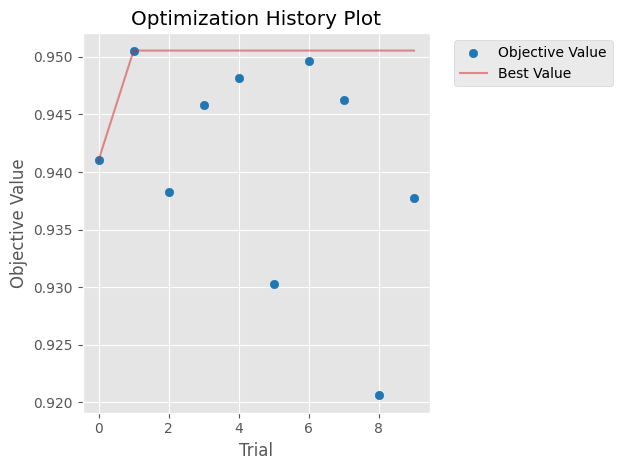

C:\Users\User\AppData\Local\Temp\ipykernel_50376\2952839772.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study)


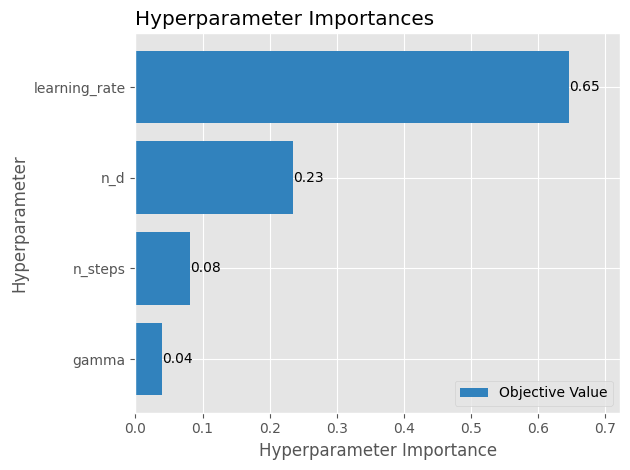

In [16]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

ax = plot_optimization_history(study)
ax.figure.tight_layout()
ax.figure.savefig(ARTIFACT_DIR / "optuna_optimization_history.png", dpi=100, bbox_inches="tight")
plt.show()

ax = plot_param_importances(study)
ax.figure.tight_layout()
ax.figure.savefig(ARTIFACT_DIR / "optuna_param_importances.png", dpi=100, bbox_inches="tight")
plt.show()


### Train the final model with the best hyperparameters

Refit a TabNet model using the winning trial's parameters. We keep the validation set for early stopping (so the final model is comparable to the tuning objective), then evaluate on the untouched test set below.

In [18]:
best_params = study.best_trial.params
final_model = build_tabnet(best_params)

final_model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=["train", "valid"],
    eval_metric=["logloss"],
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False,
)

saved_path = final_model.save_model(str(ARTIFACT_DIR / "tabnet_best_model"))
print(f"Best epoch: {final_model.best_epoch}")
print(f"Model saved to: {saved_path}")


epoch 0  | loss: 0.35597 | train_logloss: 0.28008 | valid_logloss: 0.28416 |  0:00:08s
epoch 1  | loss: 0.25803 | train_logloss: 0.23611 | valid_logloss: 0.23944 |  0:00:16s
epoch 2  | loss: 0.23743 | train_logloss: 0.22899 | valid_logloss: 0.23269 |  0:00:24s
epoch 3  | loss: 0.23181 | train_logloss: 0.22355 | valid_logloss: 0.22748 |  0:00:33s
epoch 4  | loss: 0.22865 | train_logloss: 0.22479 | valid_logloss: 0.22828 |  0:00:44s
epoch 5  | loss: 0.22474 | train_logloss: 0.21803 | valid_logloss: 0.22157 |  0:00:55s
epoch 6  | loss: 0.22314 | train_logloss: 0.21574 | valid_logloss: 0.21972 |  0:01:06s
epoch 7  | loss: 0.222   | train_logloss: 0.21705 | valid_logloss: 0.22136 |  0:01:17s
epoch 8  | loss: 0.21999 | train_logloss: 0.2138  | valid_logloss: 0.21721 |  0:01:28s
epoch 9  | loss: 0.21815 | train_logloss: 0.21142 | valid_logloss: 0.21567 |  0:01:40s
epoch 10 | loss: 0.2182  | train_logloss: 0.21138 | valid_logloss: 0.21463 |  0:01:51s
epoch 11 | loss: 0.21796 | train_logloss: 0

### Training curves

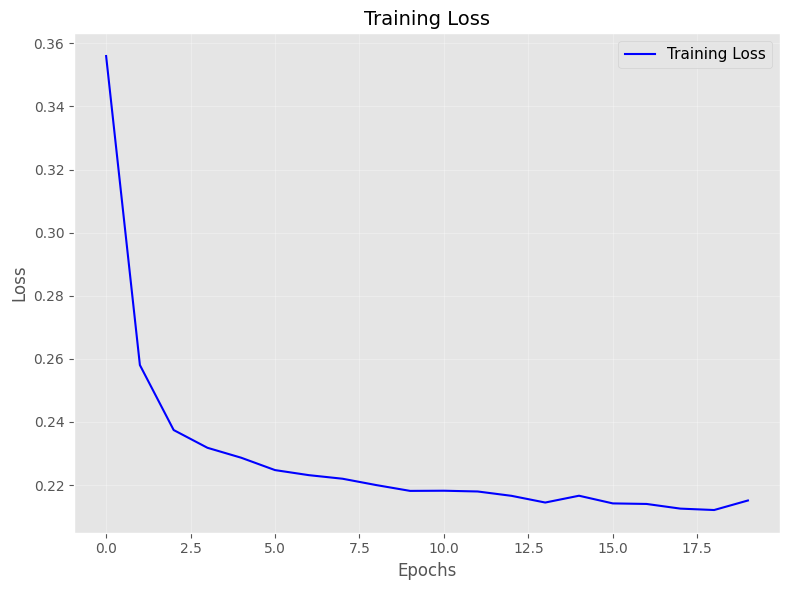

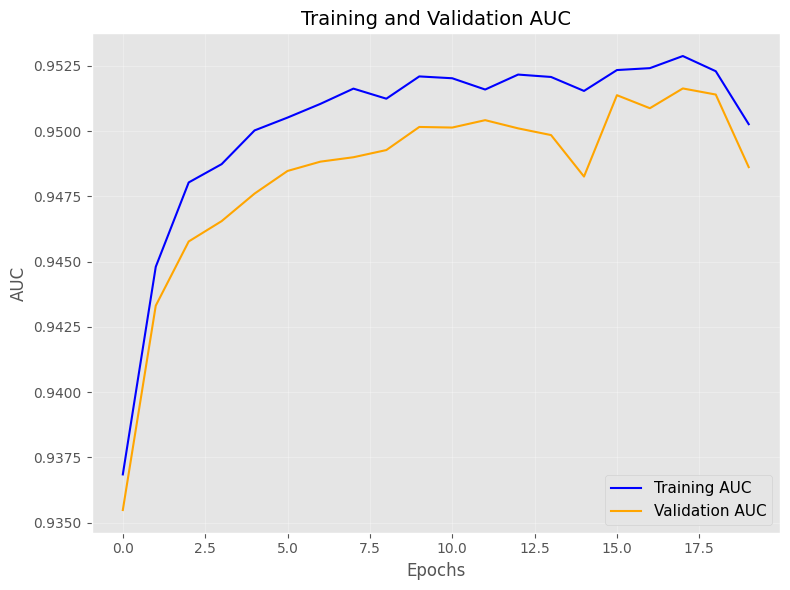

In [9]:
history = final_model.history

plt.figure(figsize=(8, 6))
plt.plot(history["loss"], label="Training Loss", color="blue")
plt.title("Training Loss", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(loc="upper right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "training_loss.png", dpi=100, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history["train_auc"], label="Training AUC", color="blue")
plt.plot(history["valid_auc"], label="Validation AUC", color="orange")
plt.title("Training and Validation AUC", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "training_auc.png", dpi=100, bbox_inches="tight")
plt.show()


### Evaluate on the held-out test set

In [10]:
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability > 0.5).astype(int)

report = classification_report(y_test, test_prediction, output_dict=True)
accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]
test_auc = roc_auc_score(y_test, test_probability)

print("CLASSIFICATION REPORT:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {test_auc:.4f}")

with open(ARTIFACT_DIR / "test_metrics.json", "w") as f:
    json.dump(
        {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auc": test_auc,
        },
        f,
        indent=2,
    )


CLASSIFICATION REPORT:
Accuracy:  0.9248
Precision: 0.8748
Recall:    0.9915
F1-score:  0.9295
AUC:       0.9509


### ROC curve

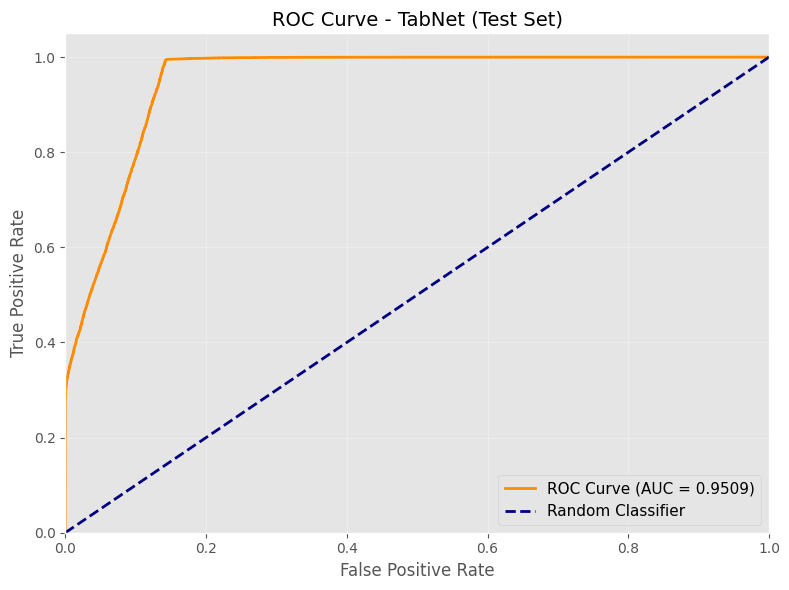

AUC Score: 0.9509


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, test_probability)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - TabNet (Test Set)", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "roc_auc_curve.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"AUC Score: {test_auc:.4f}")


### Confusion matrix

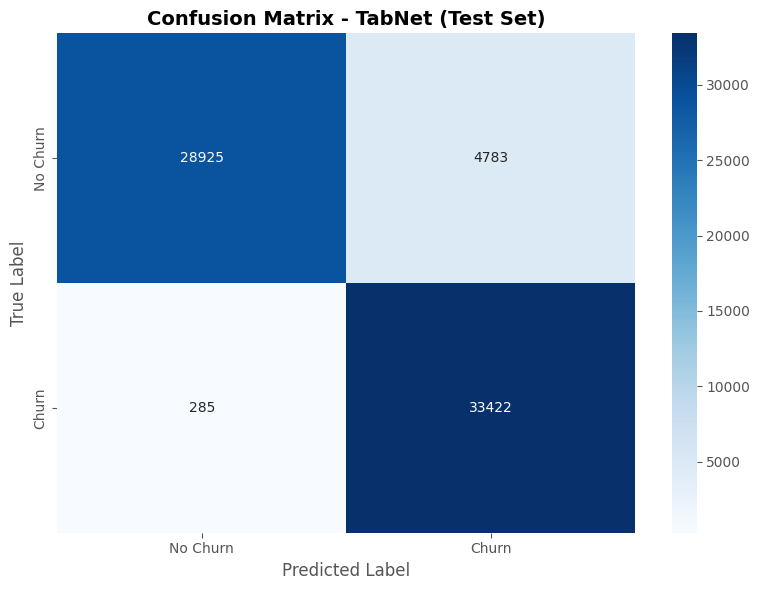

In [12]:
cm = confusion_matrix(y_test, test_prediction)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix - TabNet (Test Set)", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()


### Feature importance

TabNet exposes global feature importances (aggregated attention masks) via `feature_importances_`.

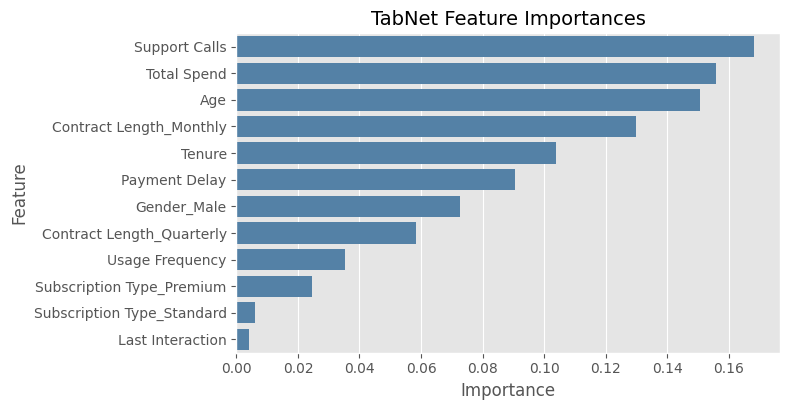

Support Calls                 0.168260
Total Spend                   0.155838
Age                           0.150720
Contract Length_Monthly       0.129735
Tenure                        0.103905
Payment Delay                 0.090422
Gender_Male                   0.072542
Contract Length_Quarterly     0.058437
Usage Frequency               0.035414
Subscription Type_Premium     0.024694
Subscription Type_Standard    0.005995
Last Interaction              0.004038
dtype: float64

In [13]:
importances = (
    pd.Series(final_model.feature_importances_, index=feature_columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, max(4, 0.35 * len(importances))))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("TabNet Feature Importances", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "feature_importances.png", dpi=100, bbox_inches="tight")
plt.show()

importances.to_frame("importance").to_csv(ARTIFACT_DIR / "feature_importances.csv")
importances


### Summary

All tuning artifacts (Optuna trial log, best hyperparameters, trained model, metrics, and plots) are written to the `tabnet_optuna_artifacts/` directory for later reference.

In [14]:
print("Artifacts written to:", ARTIFACT_DIR.resolve())
for path in sorted(ARTIFACT_DIR.glob("*")):
    print(" -", path.name)


Artifacts written to: C:\Users\User\ODL_Labs\Assignment\training\tabnet_optuna_artifacts
 - best_params.json
 - confusion_matrix.png
 - feature_importances.csv
 - feature_importances.png
 - optuna_optimization_history.png
 - optuna_param_importances.png
 - optuna_trials.csv
 - roc_auc_curve.png
 - tabnet_best_model.zip
 - test_metrics.json
 - training_auc.png
 - training_loss.png
